<a href="https://colab.research.google.com/github/BC32022/MSSP607/blob/main/WeeklyModules/Week01/Enrollment_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparing the enviroment

In [2]:
from google.colab import userdata
import os

github_token = userdata.get('Git_Key')
owner = 'Penn2001' # Replace with the GitHub repository owner
repository = 'MSSP-607' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
import subprocess
subprocess.run(['git', 'clone', clone_url])

# Navigate into the cloned repository directory (optional, but often useful)
os.chdir(repository)
print(f"Changed directory to: {os.getcwd()}")

Changed directory to: /content/MSSP-607/MSSP-607


In [3]:
pip install openpyxl

In [4]:
pip install tensorflow

In [5]:
pip install xlrd

In [6]:
pip install statsmodels

In [7]:
pip install matplotlib

In [8]:
pip install scikit-learn

In [9]:
pip install pdfkit

In [10]:
import tensorflow as tf
import keras as ks
import pandas as pd
import numpy as np
import statsmodels
#from statsmodels.tsa.statespace.sarimax import SARIMAX
import os
import openpyxl
import xlrd
import matplotlib.pyplot as plt
%matplotlib inline
import pdfkit

In [11]:
%pushd "/content/MSSP-607/"

/content/MSSP-607


['/content/MSSP-607/MSSP-607']

# Reading the data

In [12]:
enrollments = pd.read_csv("/content/MSSP-607/FTUGEnrollments.csv", encoding='utf-8', nrows=23,
                         usecols=[0,1,2])

In [13]:
enrollments

,Key,Terms,FullTimeUGEnrollments
0,1,Fall 12,2166
1,2,Spring 13,1990
2,3,Fall 13,2080
3,4,Spring 14,1929
4,5,Fall 14,1992
5,6,Spring 15,1763
6,7,Fall 15,1806
7,8,Spring 16,1601
8,9,Fall 16,1500
9,10,Spring 17,1327


In [14]:
enrollments = pd.read_excel("/content/MSSP-607/FTUGEnrollments.xlsx", nrows=22,
                           usecols=[0,1,2])

In [15]:
enrollments

,Key,Terms,FullTimeUGEnrollments
0,1,Fall 12,2166
1,2,Spring 13,1990
2,3,Fall 13,2080
3,4,Spring 14,1929
4,5,Fall 14,1992
5,6,Spring 15,1763
6,7,Fall 15,1806
7,8,Spring 16,1601
8,9,Fall 16,1500
9,10,Spring 17,1327


In [16]:
enrollments.describe()

,Key,FullTimeUGEnrollments
count,22.000000,22.000000
mean,11.454545,1538.681818
std,6.441881,320.214866
min,1.000000,1163.000000
25%,6.250000,1287.250000
50%,11.500000,1412.500000
75%,16.750000,1795.250000
max,22.000000,2166.000000


In [17]:
xlrd_book = xlrd.open_workbook("/content/MSSP-607/ControlCharts.xls", on_demand=True)
with pd.ExcelFile(xlrd_book) as xls:
    df1 = pd.read_excel(xls, "FTUGEnrollments", nrows=22, usecols=[0,1,2], index_col=1, names=["Key", "Term", "FTUGEnrollments"])
    df2 = pd.read_excel(xls, "FTFT UG", nrows=6, usecols=[0,1,2], index_col=1, names=["Key", "Term", "FTUGEnrollments"])
    df3 = pd.read_excel(xls,"TotalGREnrollments", nrows=22, usecols=[0,1,2],index_col=0)

In [18]:
df1

,Key,FTUGEnrollments
Term,,
Fall 12,1,2166
Spring 13,2,1990
Fall 13,3,2080
Spring 14,4,1929
Fall 14,5,1992
Spring 15,6,1763
Fall 15,7,1806
Spring 16,8,1601
Fall 16,9,1500


In [19]:
df1["FTUGEnrollments"].describe()

,FTUGEnrollments
count,22.000000
mean,1538.681818
std,320.214866
min,1163.000000
25%,1287.250000
50%,1412.500000
75%,1795.250000
max,2166.000000


In [20]:
df2

,Key,FTUGEnrollments
Term,,
Fall 17,1,360
Fall 18,2,421
Fall 19,3,415
Fall 20,4,411
Fall 21,5,358
Fall 22,6,392


In [21]:
df2["FTUGEnrollments"].describe()

,FTUGEnrollments
count,6.000000
mean,392.833333
std,27.952937
min,358.000000
25%,368.000000
50%,401.500000
75%,414.000000
max,421.000000


In [22]:
df3

,Terms,Total GR Enrollments
1,Fall 12,426
2,Spring 13,423
3,Fall 13,383
4,Spring 14,397
5,Fall 14,485
6,Spring 15,457
7,Fall 15,498
8,Spring 16,564
9,Fall 16,733
10,Spring 17,734


In [23]:
df3.describe()

,Total GR Enrollments
count,22.000000
mean,517.590909
std,95.562325
min,383.000000
25%,459.250000
50%,487.500000
75%,564.000000
max,734.000000


# Regression modelling

In [24]:
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

In [25]:
df1 = df1[df1["Key"] >= 10]
df1["FTUGEnrollments"].values

array([1327, 1413, 1263, 1412, 1274, 1384, 1229, 1441, 1222, 1357, 1212,
       1327, 1163])

In [26]:
data = np.array(df1["FTUGEnrollments"]).tolist()
index = np.array([
          '2017-06-30',
          '2017-12-31',
          '2018-06-30',
          '2018-12-31',
          '2019-06-30',
          '2019-12-31',
          '2020-06-30',
          '2020-12-31',
          '2021-06-30',
          '2021-12-31',
          '2022-06-30',
          '2022-12-31',
          '2023-06-30'])

In [27]:
index = pd.DatetimeIndex(index, freq='infer')
index

DatetimeIndex(['2017-06-30', '2017-12-31', '2018-06-30', '2018-12-31',
               '2019-06-30', '2019-12-31', '2020-06-30', '2020-12-31',
               '2021-06-30', '2021-12-31', '2022-06-30', '2022-12-31',
               '2023-06-30'],
              dtype='datetime64[ns]', freq='2QE-DEC')

In [28]:
aust=pd.DataFrame(data,index, columns=['FTUGEnrollments'])
aust



,FTUGEnrollments
2017-06-30,1327
2017-12-31,1413
2018-06-30,1263
2018-12-31,1412
2019-06-30,1274
2019-12-31,1384
2020-06-30,1229
2020-12-31,1441
2021-06-30,1222
2021-12-31,1357


Figure 1.1: Full Time UG Enrollments between Spring 2017 and Spring 2023.


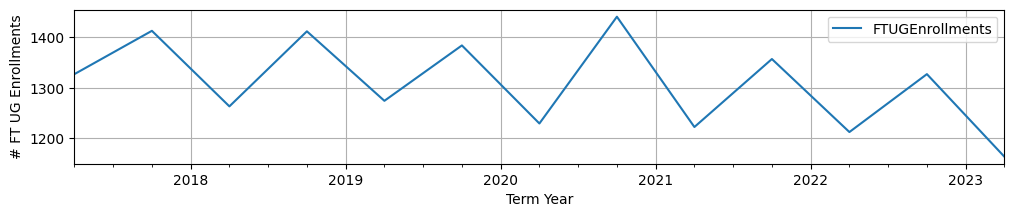

In [29]:
ax = aust.plot(figsize=(12, 2), grid=True)
ax.set_xlabel("Term Year")
ax.set_ylabel("# FT UG Enrollments")
print("Figure 1.1: Full Time UG Enrollments between Spring 2017 and Spring 2023.")

In [30]:
fit1 = SimpleExpSmoothing(aust, initialization_method='estimated').fit(smoothing_level=0.2, optimized=False)
fcast1 = fit1.forecast(6).rename(r"Forecast")
fcast1

,Forecast
2023-12-31,1280.695336
2024-06-30,1280.695336
2024-12-31,1280.695336
2025-06-30,1280.695336
2025-12-31,1280.695336
2026-06-30,1280.695336


Figure 1.2: FRCST: Full Time UG Enrollments between Spring 2017 and Spring 2026.


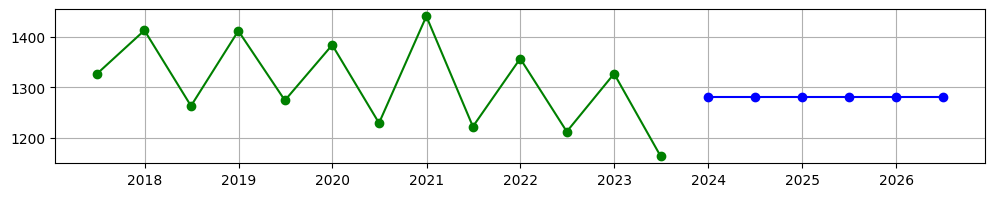

In [31]:
plt.figure(figsize=(12, 2))
plt.grid(True)
plt.plot(aust, marker='o', color='green')
plt.plot(fcast1, marker="o", color="blue")
print("Figure 1.2: FRCST: Full Time UG Enrollments between Spring 2017 and Spring 2026.")

In [32]:
print(fit1.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:        FTUGEnrollments   No. Observations:                   13
Model:             SimpleExpSmoothing   SSE                         108768.920
Optimized:                      False   AIC                            121.416
Trend:                           None   BIC                            122.546
Seasonal:                        None   AICC                           126.416
Seasonal Periods:                None   Date:                 Fri, 25 Sep 2026
Box-Cox:                        False   Time:                         12:14:38
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.2000000                alpha                False
initial_level              1352.7333                

In [33]:
fit2 = ExponentialSmoothing(aust, seasonal='add', trend=None).fit(optimized=True)


In [34]:
fcast2 = fit2.forecast(6).rename(r"Forecast")
fcast2

,Forecast
2023-12-31,1291.019189
2024-06-30,1153.639103
2024-12-31,1324.929764
2025-06-30,1166.802015
2025-12-31,1291.019189
2026-06-30,1153.639103


In [35]:
print(fit2.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:          FTUGEnrollments   No. Observations:                   13
Model:             ExponentialSmoothing   SSE                          11152.173
Optimized:                         True   AIC                             99.808
Trend:                             None   BIC                            103.197
Seasonal:                      Additive   AICC                           135.808
Seasonal Periods:                     4   Date:                 Fri, 25 Sep 2026
Box-Cox:                          False   Time:                         12:14:38
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.7895076                alpha                 True
smoothing_seasonal       

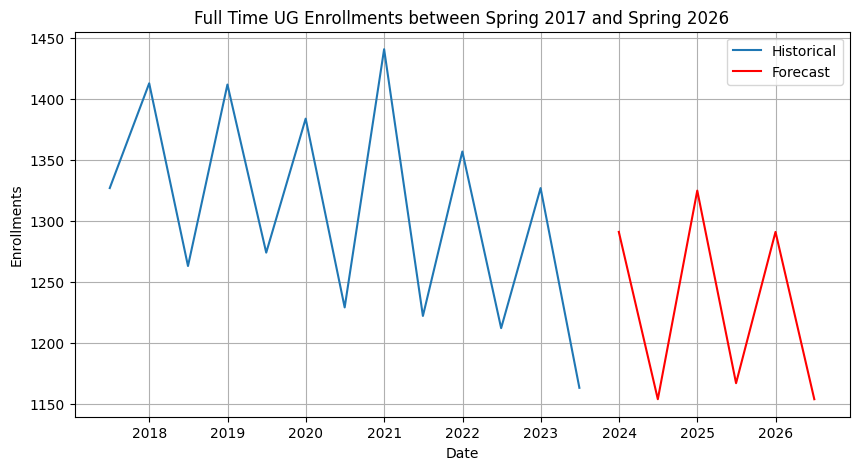

In [36]:
plt.figure(figsize=(10, 5))
plt.grid(True)
plt.plot(aust.index, aust, label='Historical')
plt.plot(fcast2.index, fcast2, label='Forecast', color='red')
plt.title('Full Time UG Enrollments between Spring 2017 and Spring 2026')
plt.xlabel('Date')
plt.ylabel('Enrollments')
plt.legend()
plt.show()

In [37]:
fit3 = Holt(aust, initialization_method='estimated').fit(smoothing_level=0.8, smoothing_trend=0.2, optimized=False)
fcast3 = fit3.forecast(6).rename(r"$\alpha=0.2$")

Figure 1.3: FRCST: Full Time UG Enrollments between Spring 2017 and Spring 2026.


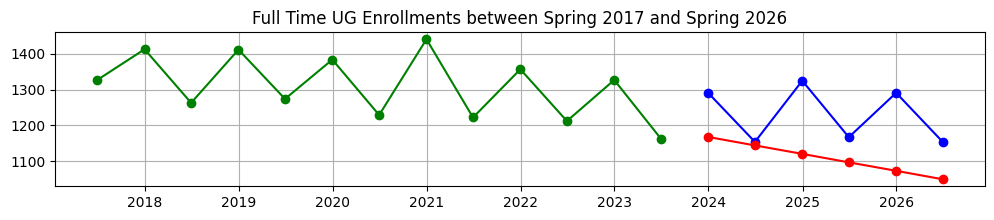

In [38]:
plt.figure(figsize=(12, 2))
plt.grid(True)
plt.plot(aust, marker='o', color='green')
plt.plot(fcast2, marker="o", color="blue")
plt.plot(fcast3, marker="o", color="red")
plt.title('Full Time UG Enrollments between Spring 2017 and Spring 2026')
plt.savefig('Forecast 3.pdf')
print("Figure 1.3: FRCST: Full Time UG Enrollments between Spring 2017 and Spring 2026.")

In [39]:
print(fit3.summary())

                              Holt Model Results                              
Dep. Variable:        FTUGEnrollments   No. Observations:                   13
Model:                           Holt   SSE                         227160.042
Optimized:                      False   AIC                            134.990
Trend:                       Additive   BIC                            137.250
Seasonal:                        None   AICC                           148.990
Seasonal Periods:                None   Date:                 Fri, 25 Sep 2026
Box-Cox:                        False   Time:                         12:14:42
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8000000                alpha                False
smoothing_trend            0.2000000                

In [40]:
fcast3

,$\alpha=0.2$
2023-12-31,1167.515958
2024-06-30,1143.811050
2024-12-31,1120.106142
2025-06-30,1096.401234
2025-12-31,1072.696326
2026-06-30,1048.991418


                               SARIMAX Results                                
Dep. Variable:        FTUGEnrollments   No. Observations:                   13
Model:                 ARIMA(3, 1, 1)   Log Likelihood                 -62.377
Date:                Fri, 25 Sep 2026   AIC                            134.753
Time:                        12:14:43   BIC                            137.178
Sample:                    06-30-2017   HQIC                           133.856
                         - 06-30-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.4236      0.565     -2.521      0.012      -2.531      -0.317
ar.L2         -0.7700      0.808     -0.952      0.341      -2.354       0.814
ar.L3         -0.3432      0.401     -0.857      0.3

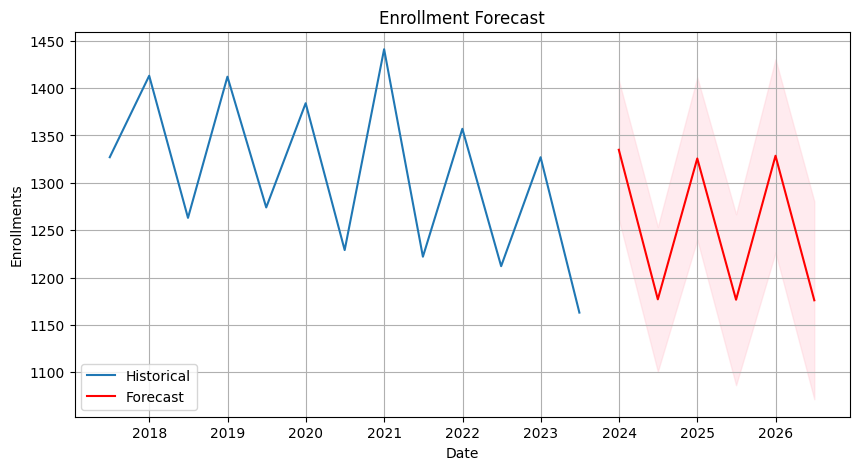

In [41]:
#In ARIMA (AutoRegressive Integrated Moving Average) models, the parameters (p, d, q)
#define how the model handles autocorrelation, trend (non-stationarity), and noise smoothing.
#p=Autoregressive order; Represents how many past observations (lags) are used to predict the current value.
#d=Differencing order;Represents how many times the data is differenced to make it stationary (i.e., remove trends).
#q=Moving average;Represents how many past forecast errors (residuals) are used to predict the current value.

#smaller AIC means a better balance of fit vs. parsimony; Parsimony means simplicity in a model — but not oversimplification.

model = ARIMA(aust, order=(3, 1, 1))  # Example parameters: p=1, d=1, q=1
fitted_model = model.fit()

print(fitted_model.summary())

forecast=fitted_model.get_forecast(steps=6)
forecast_df = forecast.summary_frame()
forecast_df

plt.figure(figsize=(10, 5))
plt.grid(True)
plt.plot(aust.index, aust, label='Historical')
plt.plot(forecast_df.index, forecast_df['mean'], label='Forecast', color='red')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='pink', alpha=0.3)
plt.title('Enrollment Forecast')
plt.xlabel('Date')
plt.ylabel('Enrollments')
plt.legend()
plt.show()


In [42]:
forecast_df

FTUGEnrollments,mean,mean_se,mean_ci_lower,mean_ci_upper
2023-12-31,1334.857268,37.394190,1261.566003,1408.148533
2024-06-30,1177.007288,38.898768,1100.767105,1253.247472
2024-12-31,1325.683331,43.693484,1240.045677,1411.320985
2025-06-30,1176.585322,46.046973,1086.334913,1266.835730
2025-12-31,1328.540505,52.046318,1226.531596,1430.549413
2026-06-30,1175.991265,53.278769,1071.566797,1280.415733


## SARIMA Modelling; seasonal AutoRegressive Integrated Moving Average extends the ARIMA model to handle seasonal patterns in time-series data — such as quarterly sales, monthly temperature cycles, or weekly website traffic

When ACF/PACF scream “strong seasonality,” you typically want seasonal differencing and possibly stronger seasonal AR/MA terms, while avoiding over-differencing.

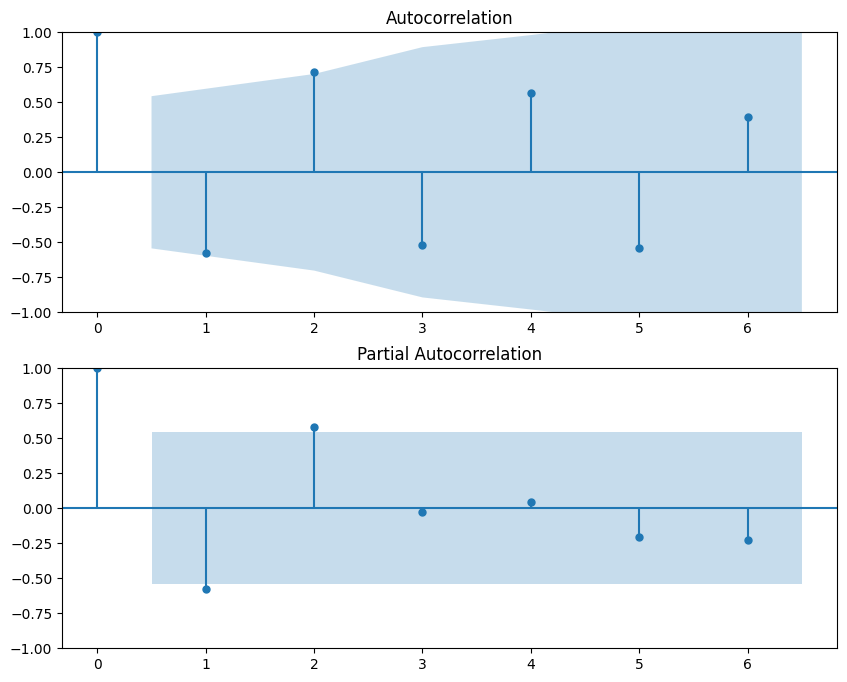

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF to help determine SARIMA orders
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(aust, ax=axes[0])
plot_pacf(aust, ax=axes[1])
plt.show()

Based on the ACF and PACF plots, we can try fitting a SARIMA model. Let's start with some common initial orders.

In [44]:
#Fit a SARIMA model
#You might need to adjust the order (p, d, q) and seasonal_order (P, D, Q, S) based on the ACF/PACF plots
#and model diagnostics #seasonal order defines how the model captures repeating seasonal
#patterns in your time series (such as monthly, quarterly, or weekly cycles).

model = SARIMAX(aust, order=(2,1 ,1), seasonal_order=(1, 1, 1, 5), trend='n')
sarima_fit = model.fit(disp=False)

sarima_fcast=sarima_fit.get_forecast(steps=6)
sarima_fcast_df = forecast.summary_frame()


print(sarima_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


                                     SARIMAX Results                                     
Dep. Variable:                   FTUGEnrollments   No. Observations:                   13
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 5)   Log Likelihood                 -37.333
Date:                           Fri, 25 Sep 2026   AIC                             86.666
Time:                                   12:14:46   BIC                             86.341
Sample:                               06-30-2017   HQIC                            82.654
                                    - 06-30-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8043      1.991     -0.404      0.686      -4.706       3.097
ar.L2          0.0567      1.704      0.033

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [45]:
sarima_fcast_df

FTUGEnrollments,mean,mean_se,mean_ci_lower,mean_ci_upper
2023-12-31,1334.857268,37.394190,1261.566003,1408.148533
2024-06-30,1177.007288,38.898768,1100.767105,1253.247472
2024-12-31,1325.683331,43.693484,1240.045677,1411.320985
2025-06-30,1176.585322,46.046973,1086.334913,1266.835730
2025-12-31,1328.540505,52.046318,1226.531596,1430.549413
2026-06-30,1175.991265,53.278769,1071.566797,1280.415733


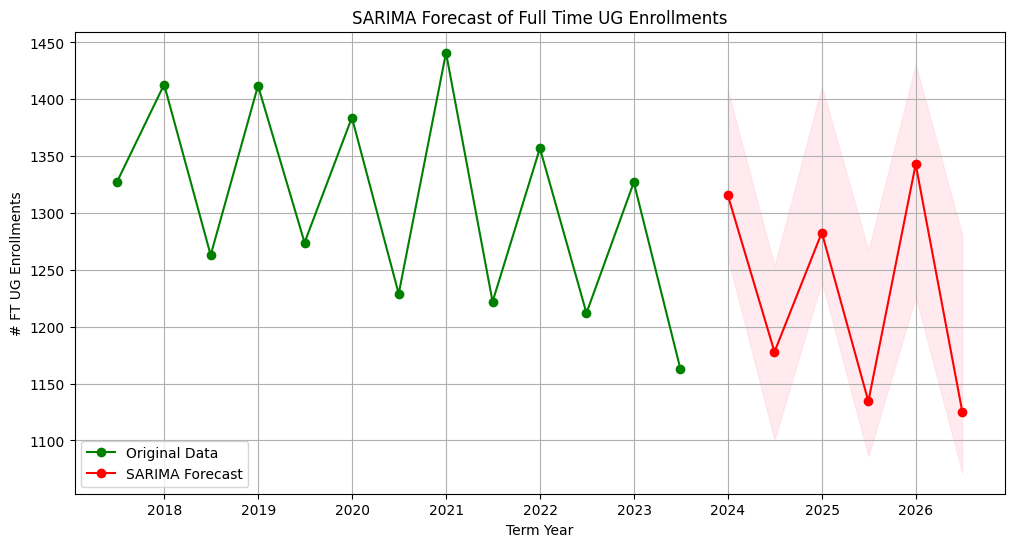

In [46]:
# Forecast future values
sarima_fcast = sarima_fit.forecast(6)

# Plot the original data and the SARIMA forecast
plt.figure(figsize=(12, 6))
plt.plot(aust, marker='o', color='green', label='Original Data')
plt.plot(sarima_fcast, marker="o", color="red", label='SARIMA Forecast')
plt.fill_between(sarima_fcast_df.index, sarima_fcast_df['mean_ci_lower'], sarima_fcast_df['mean_ci_upper'], color='pink', alpha=0.3)
plt.title('SARIMA Forecast of Full Time UG Enrollments')
plt.xlabel('Term Year')
plt.ylabel('# FT UG Enrollments')
plt.grid(True)
plt.legend()
plt.show()